<a href="https://colab.research.google.com/github/apeksha300/DeepLearning_Project/blob/main/apeksha.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
os.environ['KAGGLE_API_TOKEN'] = 'KGAT_61f5c6260017faeba681fb4a36861a25'

print("Kaggle Token set! Ready for Cell 2.")

In [ ]:
!kaggle datasets download -d vipoooool/new-plant-diseases-dataset

!unzip -q new-plant-diseases-dataset.zip -d dataset

print("Dataset downloaded and unzipped!")

Dataset URL: https://www.kaggle.com/datasets/vipoooool/new-plant-diseases-dataset
License(s): copyright-authors
100% 2.70G/2.70G [02:41<00:00, 18.0MB/s]

Dataset downloaded and unzipped!


In [ ]:
import os
import shutil

source_dir = 'dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)'
target_dir = 'apple_dataset'


for split in ['train', 'valid']:
    os.makedirs(f'{target_dir}/{split}', exist_ok=True)
    split_dir = os.path.join(source_dir, split)

    for folder in os.listdir(split_dir):
        if 'Apple' in folder:
            src_folder = os.path.join(split_dir, folder)
            dest_folder = os.path.join(target_dir, split, folder)
            shutil.copytree(src_folder, dest_folder)

print("Apple data successfully isolated!")

Apple data successfully isolated!


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = 224
BATCH_SIZE = 32
train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    zoom_range=0.25,
    horizontal_flip=True,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.15,
    brightness_range=[0.8,1.2]
)

val_gen = ImageDataGenerator(rescale=1./255)

train_data = train_gen.flow_from_directory(
    'apple_dataset/train',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_data = val_gen.flow_from_directory(
    'apple_dataset/valid',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

print("Classes found:", train_data.class_indices)

In [ ]:
from tensorflow.keras import layers, models

num_classes = len(train_data.class_indices)

model = models.Sequential([
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,476 (42.61 MB)

 Trainable params: 11,169,476 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early = EarlyStopping(
    monitor='val_accuracy',
    patience=4,
    restore_best_weights=True
)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    train_data,
    epochs=10,
    validation_data=val_data,
    callbacks=[early_stop]
)

print("Training complete!")

Epoch 1/5
243/243 ━━━━━━━━━━━━━━━━━━━━ 130s 495ms/step - accuracy: 0.6921 - loss: 0.7398 - val_accuracy: 0.7869 - val_loss: 0.6849
Epoch 2/5
243/243 ━━━━━━━━━━━━━━━━━━━━ 112s 461ms/step - accuracy: 0.8515 - loss: 0.4046 - val_accuracy: 0.8214 - val_loss: 0.5671
Epoch 3/5
243/243 ━━━━━━━━━━━━━━━━━━━━ 112s 459ms/step - accuracy: 0.8906 - loss: 0.3098 - val_accuracy: 0.9156 - val_loss: 0.2253
Epoch 4/5
243/243 ━━━━━━━━━━━━━━━━━━━━ 113s 462ms/step - accuracy: 0.9247 - loss: 0.2115 - val_accuracy: 0.8770 - val_loss: 0.3399
Epoch 5/5
243/243 ━━━━━━━━━━━━━━━━━━━━ 112s 461ms/step - accuracy: 0.9337 - loss: 0.1831 - val_accuracy: 0.9496 - val_loss: 0.1361
Training complete!


In [ ]:
train_loss, train_acc = model.evaluate(train_data)

print("Training Loss:{:.2f}%".format(train_loss*100))
print("Training Accuracy:{:.2f}%".format(train_acc*100))

val_loss, val_acc = model.evaluate(val_data)

print("Validation Loss:{:.2f}%".format(val_loss*100))
print("Validation Accuracy:{:.2f}%".format(val_acc*100))

243/243 ━━━━━━━━━━━━━━━━━━━━ 106s 435ms/step - accuracy: 0.9409 - loss: 0.1661
Training Loss:16.61%
Training Accuracy:94.09%
61/61 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - accuracy: 0.9135 - loss: 0.2474
Validation Loss:24.74%
Validation Accuracy:91.35%


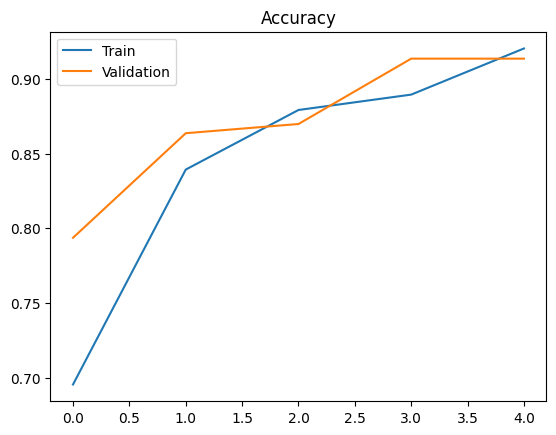

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['Train','Validation'])
plt.title("Accuracy")
plt.show()

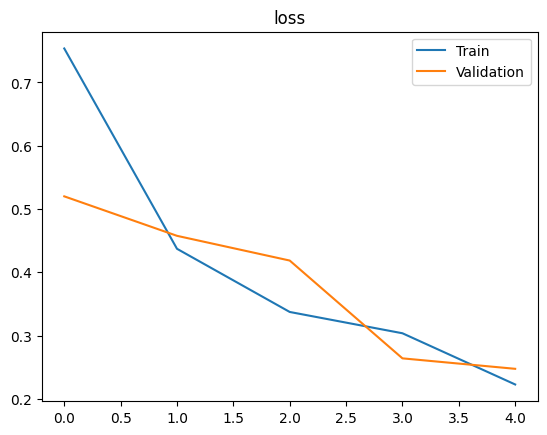

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(['Train','Validation'])
plt.title("loss")
plt.show()

In [ ]:
model.save('apple_disease_model.h5')
print("Model saved!")

Model saved!


In [ ]:
import tensorflow as tf

test_set = tf.keras.utils.image_dataset_from_directory(
    "/content/apple_dataset/valid",
    image_size=(224,224),
    batch_size=32,
    label_mode="categorical",
    shuffle=False
)

test_loss, test_acc = model.evaluate(test_set)

print("Test Accuracy:{:.2f}%".format( test_acc*100))

Found 1943 files belonging to 4 classes.
61/61 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.6752 - loss: 212.5360
Test Accuracy:87.52%


In [ ]:
import json

with open("training_hist.json", "w") as f:
    json.dump(history.history, f)

print("Training history saved!")
with open("training_hist.json", "r") as f:
    hist = json.load(f)

print(hist.keys())

Training history saved!
dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


61/61 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step
                          precision    recall  f1-score   support

      Apple___Apple_scab       0.83      0.49      0.62       504
       Apple___Black_rot       0.47      1.00      0.64       497
Apple___Cedar_apple_rust       1.00      0.60      0.75       440
         Apple___healthy       0.95      0.60      0.74       502

                accuracy                           0.68      1943
               macro avg       0.81      0.67      0.69      1943
            weighted avg       0.81      0.68      0.68      1943



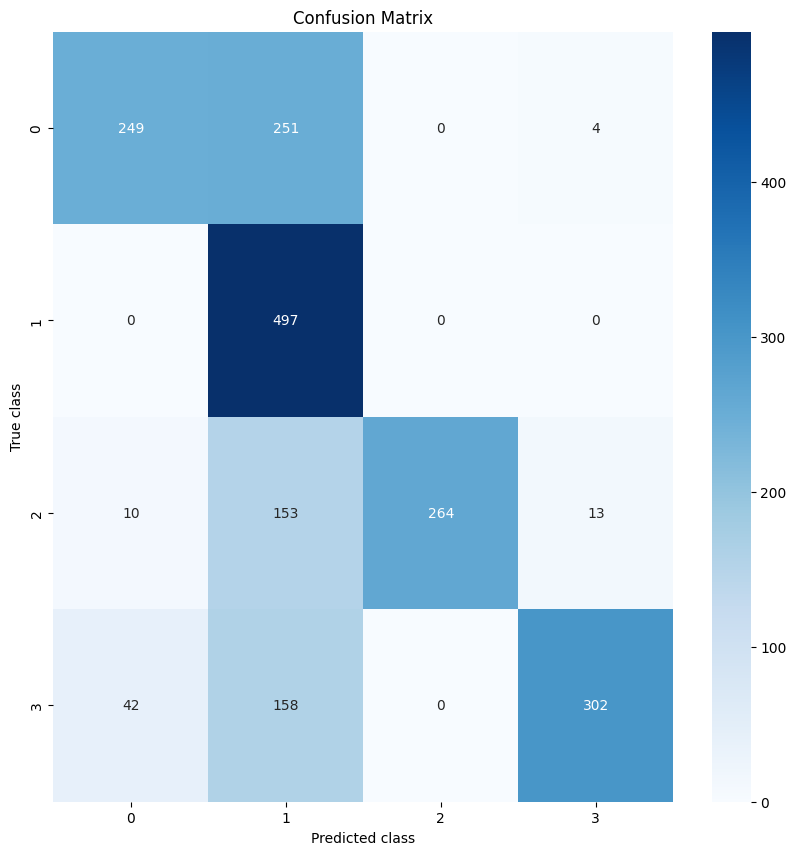

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Extract true labels
y_true = []
for images, labels in test_set:
    y_true.extend(np.argmax(labels.numpy(), axis=1))

# Get predictions
predictions = model.predict(test_set)
predicted_categories = np.argmax(predictions, axis=1)

# Get class names
class_names = test_set.class_names

print(classification_report(y_true, predicted_categories, target_names=class_names))
cn = confusion_matrix(y_true, predicted_categories)

plt.figure(figsize=(10,10))
sns.heatmap(cn, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted class")
plt.ylabel("True class")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
import gradio as gr
import tensorflow as tf
from PIL import Image
import numpy as np
import os
from google.colab import files

if not os.path.exists('apple_disease_model.h5'):
    print(" Model file not found in Colab! Please upload 'apple_disease_model.h5' from your laptop:")
    uploaded = files.upload()


print("Loading model into memory...")
model = tf.keras.models.load_model('apple_disease_model.h5')
print(" Model loaded successfully!")

class_names = ['Apple Scab', 'Black Rot', 'Cedar Apple Rust', 'Healthy']

def predict_disease(img):
    try:

        img = img.convert('RGB')
        img = img.resize((224, 224))
        img_array = tf.keras.preprocessing.image.img_to_array(img) / 255.0
        img_array = np.expand_dims(img_array, axis=0)

        prediction = model.predict(img_array)[0]
        return {class_names[i]: float(prediction[i]) for i in range(4)}
    except Exception as e:
        return {f"Error: {str(e)}": 0.0}


interface = gr.Interface(
    fn=predict_disease,
    inputs=gr.Image(type="pil"),
    outputs=gr.Label(num_top_classes=4),
    title=" Apple Tree Disease Classifier",
    description="Upload an image of an apple leaf to instantly detect its health status."
)

interface.launch(share=True)

Loading model into memory...
 Model loaded successfully!
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://74ddeff76d13b70f14.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
